/Users/evanhoyt/exoplanet-env/lib/python3.9/site-packages/lightkurve/search.py:420: LightkurveWarning: Warning: 50 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


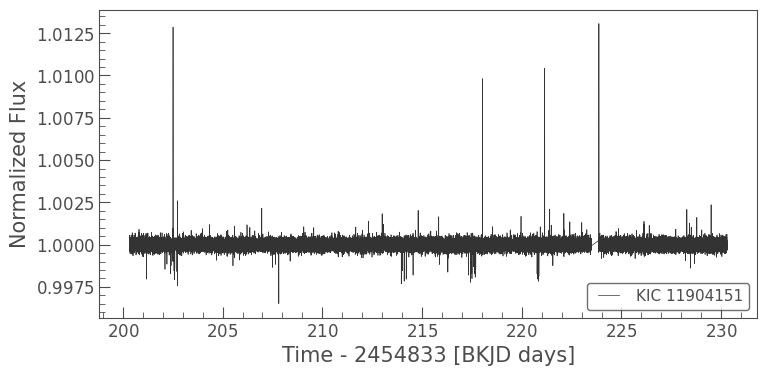

In [4]:
import lightkurve as lk
import matplotlib.pyplot as plt

lc = lk.search_lightcurve("Kepler-10", mission="Kepler").download()

lc = lc.remove_nans().flatten()

lc.plot()
plt.show()

In [5]:
import numpy as np
from astropy.timeseries import BoxLeastSquares

# Extract data
time = lc.time.value
flux = lc.flux.value

# Normalize flux (important)
flux = flux / np.median(flux)

# Create BLS model
model = BoxLeastSquares(time, flux)

# Search ranges
periods = np.linspace(0.5, 10, 3000)   # days
durations = np.linspace(0.05, 0.3, 10)

# Run BLS
results = model.power(periods, durations)

# Best period
best_period = periods[np.argmax(results.power)]

print("Best period:", best_period)

Best period: 9.65788596198733


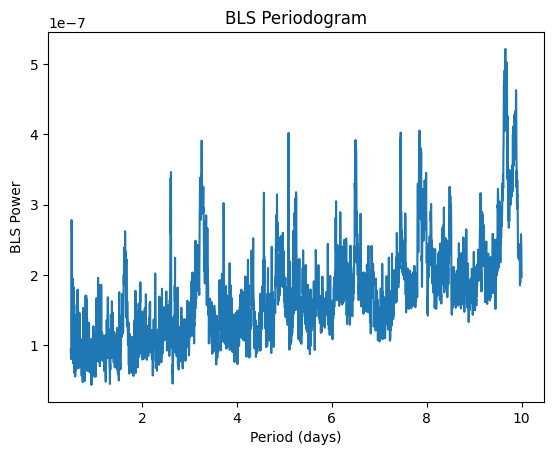

In [6]:
import matplotlib.pyplot as plt

plt.plot(results.period, results.power)
plt.xlabel("Period (days)")
plt.ylabel("BLS Power")
plt.title("BLS Periodogram")
plt.show()

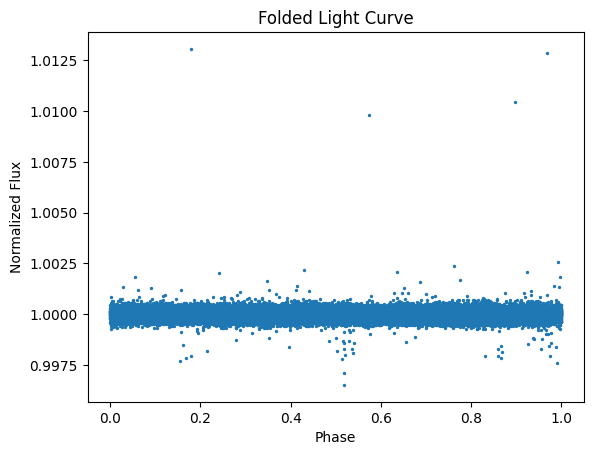

In [7]:
phase = (time % best_period) / best_period

plt.scatter(phase, flux, s=2)
plt.xlabel("Phase")
plt.ylabel("Normalized Flux")
plt.title("Folded Light Curve")
plt.show()

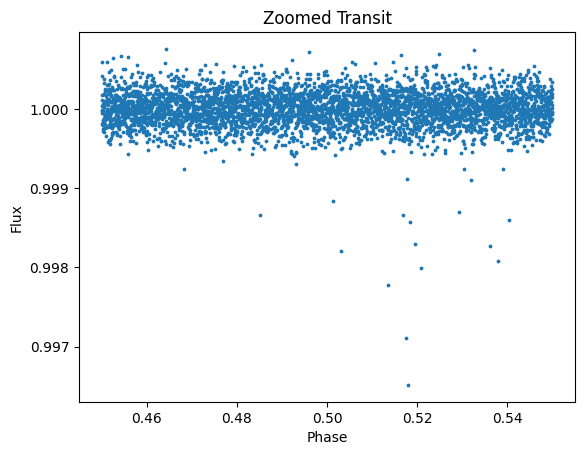

In [8]:
mask = (phase > 0.45) & (phase < 0.55)

plt.scatter(phase[mask], flux[mask], s=3)
plt.xlabel("Phase")
plt.ylabel("Flux")
plt.title("Zoomed Transit")
plt.show()